In [2]:
import json
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# Load data

In [3]:
# number of jobs
job_number = 100

# number of rounds
rounds_list = range(1,11)
# number of preselected rounds
preselect_list = range(0,4)

# Save logical error
Logical_Error = np.full((len(preselect_list),len(rounds_list)),np.nan)
# Save logical error uncertainty
Logical_Error_u = np.full((len(preselect_list),len(rounds_list)),np.nan)

# loop through preselected rounds
for preselect in preselect_list:
    # loop through number of rounds
    for index_rounds, rounds in enumerate(rounds_list):         
        nb_accepted = 0
        nb_fail = 0
        
        # loop through jobs
        for index in range(job_number):
            result = json.load(open(f'./Results/result_{rounds}_{index}.json', 'r'))

            if preselect < len(result['preselected&accepted&fail']):
                nb_fail += result['preselected&accepted&fail'][preselect]
                nb_accepted += result['preselected&accepted'][preselect]

        if nb_accepted != 0:
            Logical_Error[preselect,index_rounds] = nb_fail/nb_accepted
            Logical_Error_u[preselect,index_rounds] = 1.96*np.sqrt(nb_fail/nb_accepted**2*(1-nb_fail/nb_accepted))

In [4]:
# mean number of rounds depending on preselection
mean_rounds_list = np.load("Mean_rounds.npy")

# Logical error

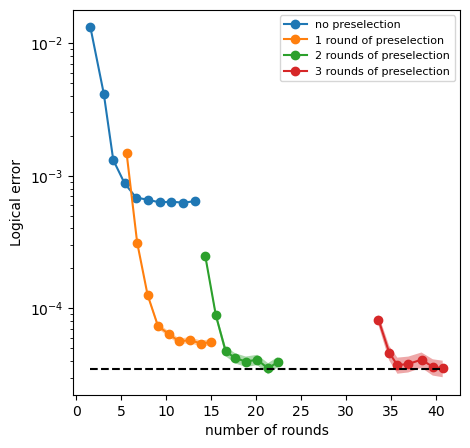

In [9]:
plt.figure(figsize=(5, 5))         

# loop through preselected rounds
for preselect in preselect_list:
    # logical error
    if preselect == 0:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'no preselection')
    elif preselect == 1:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'1 round of preselection')
    else:
        plt.plot(mean_rounds_list[:,preselect],Logical_Error[preselect],'-o',label = f'{preselect} rounds of preselection')
    # error bar
    plt.fill_between(mean_rounds_list[:,preselect],Logical_Error[preselect] - Logical_Error_u[preselect],
                     Logical_Error[preselect] + Logical_Error_u[preselect], alpha=0.4)
    
# theoritcal 35p^3 of distillation
plt.plot([np.min(mean_rounds_list),np.max(mean_rounds_list)],[35*(2/3*5e-3 + 5e-3 + 5e-3/3)**3]*2,'--',c='k')

plt.legend(loc = 'upper right',fontsize = 8)
plt.yscale('log')
plt.xlabel('number of rounds')
plt.ylabel('Logical error')
plt.show()

In [8]:
import pandas as pd
column_names = [f"{i} min rounds" for i in range(1,11)]
row_names = [f"preselection {i} round(s)" for i in range(4)]
df = pd.DataFrame(Logical_Error, columns=column_names, index=row_names)
pd.set_option('display.float_format', '{:.2e}'.format)
df

,1 min rounds,2 min rounds,3 min rounds,4 min rounds,5 min rounds,6 min rounds,7 min rounds,8 min rounds,9 min rounds,10 min rounds
preselection 0 round(s),1.32e-02,4.17e-03,1.31e-03,8.76e-04,6.85e-04,6.58e-04,6.29e-04,6.37e-04,6.25e-04,6.44e-04
preselection 1 round(s),NaN,1.48e-03,3.13e-04,1.26e-04,7.35e-05,6.40e-05,5.62e-05,5.76e-05,5.42e-05,5.55e-05
preselection 2 round(s),NaN,NaN,2.47e-04,8.85e-05,4.73e-05,4.21e-05,3.96e-05,4.09e-05,3.51e-05,3.93e-05
preselection 3 round(s),NaN,NaN,NaN,8.19e-05,4.62e-05,3.72e-05,3.80e-05,4.10e-05,3.61e-05,3.52e-05
